In [39]:
%matplotlib inline

In [64]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import pm4py
import os
import networkx as nx

In [10]:
def get_event_log_info(log):
    try:
        # Calculate basic statistics about the event log
        num_cases = log['case:concept:name'].nunique()
        num_events = log['EventID'].nunique()
        num_offers = log['OfferID'].nunique()

        # Calculate the number of unique process variants
        num_process_variants = len(pm4py.get_variants(log))

        # Calculate coverage of the most common process variant
        variants = pm4py.get_variants(log)
        variant_counts = pd.Series(variants).sort_values(ascending=False)
        variant_coverage = variant_counts.cumsum() / variant_counts.sum()
        num_variants_covered_80_percent = (variant_coverage <= 0.8).sum() + 1  # +1 to include the variant that reaches 80%

        # Get length of each case == number of events per case
        len_cases = log.groupby('case:concept:name').size()
        mean_case_length = len_cases.mean()
        std_case_length = len_cases.std()

        duration_cases = pm4py.stats.get_all_case_durations(log)
        mean_case_duration = np.mean(duration_cases)
        std_case_duration = np.std(duration_cases)

        def format_duration(seconds):
            if seconds < 60:
                return f"{seconds:.2f} seconds"
            elif seconds < 3600:
                return f"{seconds / 60:.2f} minutes"
            elif seconds < 86400:
                return f"{seconds / 3600:.2f} hours"
            else:
                return f"{seconds / 86400:.2f} days"

        stats = pd.DataFrame({
            'Metric': [
                'Number of cases',
                'Number of events',
                'Number of offers',
                'Number of process variants',
                'Number of variants covering 80% of cases',
                'Mean case length',
                'Std case length',
                'Mean case duration',
                'Std case duration',
            ],
            'Value': [
                num_cases,
                num_events,
                num_offers,
                num_process_variants,
                num_variants_covered_80_percent,
                mean_case_length,
                std_case_length,
                format_duration(mean_case_duration),
                format_duration(std_case_duration)
            ]
        }).set_index('Metric')

        return stats

    except Exception as e:
        print(f"Error processing event log: {e}")
        return None
    
def get_attributes(log):
    try:
        case_attr_labels = [col for col in log.columns if col.startswith('case:')]
        event_attr_labels = [col for col in log.columns if not col.startswith('case:')]

        num_case_attr_labels = len(case_attr_labels)
        num_event_attr_labels = len(event_attr_labels)

        event_cols = [col for col in log.columns if not col.startswith('case:')]
        num_categorical_event_attrs = sum(log[col].dtype in ('object', 'category') for col in event_cols)
        stats = pd.DataFrame({
            'Metric': [
                'Number of case attribute labels',
                'Number of event attribute labels',
                'Number of categorical event attributes'
            ],
            'Value': [
                num_case_attr_labels,
                num_event_attr_labels,
                num_categorical_event_attrs
            ]
        }).set_index('Metric')
        return stats
    except Exception as e:
        print(f"Error processing event log: {e}")
        return None    

In [3]:
raw_event_log = pm4py.read_xes("../data/BPIChallenge2017.xes.gz")

/Users/danielsich/.local/share/virtualenvs/BPIC_17_Data2Process-MrbUe94b/lib/python3.13/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

In [16]:
print("raw event log info:\n")
print(get_event_log_info(raw_event_log), "\n")
print ("raw event log attributes:\n")
print(get_attributes(raw_event_log))

raw event log info:

                                               Value
Metric                                              
Number of cases                                31509
Number of events                             1202267
Number of offers                               42995
Number of process variants                     15930
Number of variants covering 80% of cases        9629
Mean case length                           38.156305
Std case length                            16.715308
Mean case duration                        21.90 days
Std case duration                         13.17 days 

raw event log attributes:

                                        Value
Metric                                       
Number of case attribute labels             4
Number of event attribute labels           15
Number of categorical event attributes      2


In [17]:
complete_event_log = raw_event_log[raw_event_log['lifecycle:transition'] == 'complete']
print("complete event log info:\n")
print(get_event_log_info(complete_event_log), "\n")
print("Complete event log attributes:\n")
print(get_attributes(complete_event_log))

complete event log info:

                                               Value
Metric                                              
Number of cases                                31509
Number of events                              475306
Number of offers                               42995
Number of process variants                      5623
Number of variants covering 80% of cases         610
Mean case length                           15.084769
Std case length                             4.596201
Mean case duration                        21.85 days
Std case duration                         12.94 days 

Complete event log attributes:

                                        Value
Metric                                       
Number of case attribute labels             4
Number of event attribute labels           15
Number of categorical event attributes      2


- test

In [7]:
print("end activities: ", pm4py.stats.get_end_activities(complete_event_log))

end activities:  {'A_Pending': 10288, 'W_Validate application': 4036, 'O_Cancelled': 14051, 'O_Refused': 1977, 'W_Call incomplete files': 631, 'A_Cancelled': 119, 'W_Complete application': 63, 'A_Denied': 20, 'W_Call after offers': 135, 'W_Assess potential fraud': 93, 'A_Incomplete': 29, 'A_Validating': 3, 'O_Sent (online only)': 12, 'O_Sent (mail and online)': 20, 'A_Complete': 30, 'O_Returned': 2}


- filter down to only logical endings

In [18]:
filtered_event_log = pm4py.filter_end_activities(complete_event_log, ["O_Cancelled", "A_Pending", "O_Refused"], retain = True)
print("filtered event log info:\n")
print(get_event_log_info(filtered_event_log), "\n")
print("Filtered event log attributes:\n")
print(get_attributes(filtered_event_log))

filtered event log info:

                                               Value
Metric                                              
Number of cases                                26316
Number of events                              393164
Number of offers                               36668
Number of process variants                      4430
Number of variants covering 80% of cases         401
Mean case length                           14.940112
Std case length                             4.745395
Mean case duration                        22.61 days
Std case duration                         12.62 days 

Filtered event log attributes:

                                        Value
Metric                                       
Number of case attribute labels             4
Number of event attribute labels           15
Number of categorical event attributes      2


In [52]:
def display_trailing_case_length_plot(log, target_year=None, window_days=7):
    """
    Computes the trailing mean of case lengths grouped by case start dates
    and displays it inline within a Jupyter Notebook cell.
    
    Parameters:
    - log: A pm4py EventLog object, EventStream, or a pandas DataFrame.
    - target_year: int (optional), filter for a specific calendar year (e.g., 2017). 
                   If None, it automatically processes the entire log timeframe.
    - window_days: int, size of the sliding historical lookback window (default: 7).
    """
    # 1. Standardize the log format into a regular DataFrame
    df = pm4py.convert_to_dataframe(log)
    
    # 2. Ensure timestamps are in proper datetime format
    df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])
    
    # 3. Calculate case length (event counts) and case start date per process instance
    case_df = df.groupby('case:concept:name').agg(
        case_length=('time:timestamp', 'count'),
        start_date=('time:timestamp', 'min')
    ).reset_index()
    
    # 4. Filter by year only if a target year is explicitly provided
    if target_year is not None:
        case_df = case_df[case_df['start_date'].dt.year == target_year]
        if case_df.empty:
            available_years = df['time:timestamp'].dt.year.unique()
            print(f"Warning: No cases start in {target_year}. Available years in this log: {available_years}")
            return
    
    # 5. Collapse timestamps to daily granularity dates
    case_df['start_date_only'] = case_df['start_date'].dt.date
    
    # 6. Chronologically sort and compute the daily average case lengths
    daily_df = case_df.groupby('start_date_only')['case_length'].mean().reset_index()
    daily_df = daily_df.sort_values('start_date_only')
    
    # 7. Compute the trailing rolling mean window
    daily_df['trailing_mean'] = daily_df['case_length'].rolling(window=window_days, min_periods=1).mean()
    
    # 8. Initialize a fresh standalone figure canvas
    plt.figure(figsize=(12, 6))
    
    # 9. Plot raw daily data as a background reference layer
    #plt.plot(daily_df['start_date_only'], daily_df['case_length'], 
     #        label='Daily Mean Case Length', color='lightblue', alpha=0.7, linestyle='--')
    
    # 10. Overlay the smooth trailing mean trend curve
    plt.plot(daily_df['start_date_only'], daily_df['trailing_mean'], 
             label=f'{window_days}-Day Trailing Mean', color='navy', linewidth=2)
    
    # 11. Add chart labels, titles, and grid structures
    title_suffix = f"({target_year})" if target_year else "(All Available Data)"
    plt.title(f'Trailing Mean Case Length by Case Start Date {title_suffix}', fontsize=14, fontweight='bold')
    plt.xlabel('Case Start Date', fontsize=12)
    plt.ylabel('Mean Case Length (Number of Events)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=10)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # 12. Force Jupyter to render the chart immediately
    plt.show()


def display_trailing_case_duration_days(log, target_year=None, window_days=7):
    """
    Computes the trailing mean of case durations (in days) grouped by case start dates
    and displays it inline within a Jupyter Notebook cell.
    
    Parameters:
    - log: A pm4py EventLog object, EventStream, or a pandas DataFrame.
    - target_year: int (optional), filter for a specific calendar year (e.g., 2017).
    - window_days: int, size of the sliding historical lookback window (default: 7).
    """
    # 1. Convert the log structure to a standard pandas DataFrame
    df = pm4py.convert_to_dataframe(log)
    df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])
    
    # 2. Extract start date, end date, and compute duration in days per case
    case_df = df.groupby('case:concept:name').agg(
        start_date=('time:timestamp', 'min'),
        end_date=('time:timestamp', 'max')
    ).reset_index()
    
    # Calculate the elapsed duration in days (total seconds divided by 86,400)
    case_df['case_duration_days'] = (case_df['end_date'] - case_df['start_date']).dt.total_seconds() / 86400.0
    
    # 3. Filter by year if specified
    if target_year is not None:
        case_df = case_df[case_df['start_date'].dt.year == target_year]
        if case_df.empty:
            print(f"Warning: No cases start in {target_year}.")
            return
            
    case_df['start_date_only'] = case_df['start_date'].dt.date
    
    # 4. Compute daily averages and rolling mean trend line
    daily_df = case_df.groupby('start_date_only')['case_duration_days'].mean().reset_index()
    daily_df = daily_df.sort_values('start_date_only')
    daily_df['trailing_mean'] = daily_df['case_duration_days'].rolling(window=window_days, min_periods=1).mean()
    
    # 5. Initialize figure axes using the reliable object-oriented pattern
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 6. Plot volatile daily means (background layer)
    #ax.plot(daily_df['start_date_only'], daily_df['case_duration_days'], 
     #       label='Daily Mean Duration', color='lightcoral', alpha=0.6, linestyle='--')
    
    # 7. Plot smoothed trailing mean (prominent foreground layer)
    ax.plot(daily_df['start_date_only'], daily_df['trailing_mean'], 
            label=f'{window_days}-Day Trailing Mean', color='darkred', linewidth=2)
    
    # 8. Chart configurations and styling
    title_suffix = f"({target_year})" if target_year else "(All Available Data)"
    ax.set_title(f'Trailing Mean Case Duration (Days) by Case Start Date {title_suffix}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Case Start Date', fontsize=12)
    ax.set_ylabel('Mean Case Duration (Days)', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=10)
    
    # Rotate date labels cleanly
    fig.autofmt_xdate(rotation=45)
    plt.tight_layout()
    
    # 9. Force immediate render block in Jupyter Notebooks
    plt.show()


def display_combined_trailing_metrics_plot(log, target_year=None, window_days=7):
    """
    Computes and displays both the 7-day trailing case length (events) and 
    trailing case duration (days) on a single dual-axis graph in a Jupyter cell.
    
    Parameters:
    - log: A pm4py EventLog object, EventStream, or a pandas DataFrame.
    - target_year: int (optional), filter for a specific calendar year (e.g., 2017).
    - window_days: int, size of the sliding historical lookback window (default: 7).
    """
    # 1. Standardize log format to a standard pandas DataFrame
    df = pm4py.convert_to_dataframe(log)
    df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])
    
    # 2. Extract metrics per process instance
    case_df = df.groupby('case:concept:name').agg(
        start_date=('time:timestamp', 'min'),
        end_date=('time:timestamp', 'max'),
        case_length=('time:timestamp', 'count')
    ).reset_index()
    
    # Calculate duration in fractions of days
    case_df['case_duration_days'] = (case_df['end_date'] - case_df['start_date']).dt.total_seconds() / 86400.0
    
    # 3. Filter by year if specified
    if target_year is not None:
        case_df = case_df[case_df['start_date'].dt.year == target_year]
        if case_df.empty:
            print(f"Warning: No cases start in {target_year}.")
            return
            
    case_df['start_date_only'] = case_df['start_date'].dt.date
    
    # 4. Chronologically aggregate daily metrics
    daily_df = case_df.groupby('start_date_only').agg(
        mean_length=('case_length', 'mean'),
        mean_duration=('case_duration_days', 'mean')
    ).reset_index()
    daily_df = daily_df.sort_values('start_date_only')
    
    # 5. Compute both trailing rolling means
    daily_df['trailing_length'] = daily_df['mean_length'].rolling(window=window_days, min_periods=1).mean()
    daily_df['trailing_duration'] = daily_df['mean_duration'].rolling(window=window_days, min_periods=1).mean()
    
    # 6. Initialize the robust subplots pattern
    fig, ax1 = plt.subplots(figsize=(13, 6))
    
    # --- Primary Y-Axis: Case Length (Events) ---
    color_len = 'navy'
    ax1.plot(daily_df['start_date_only'], daily_df['mean_length'], color='lightblue', alpha=0.3, linestyle='--')
    line1, = ax1.plot(daily_df['start_date_only'], daily_df['trailing_length'], 
                     color=color_len, linewidth=2.5, label=f'{window_days}-Day Trailing Length (Events)')
    
    ax1.set_xlabel('Case Start Date', fontsize=12)
    ax1.set_ylabel('Mean Case Length (Events)', color=color_len, fontsize=12)
    ax1.tick_params(axis='y', labelcolor=color_len)
    ax1.grid(True, linestyle=':', alpha=0.5)
    
    # --- Secondary Y-Axis: Case Duration (Days) ---
    ax2 = ax1.twinx()  # Share the x-axis for dates
    color_dur = 'darkred'
    ax2.plot(daily_df['start_date_only'], daily_df['mean_duration'], color='lightcoral', alpha=0.3, linestyle='--')
    line2, = ax2.plot(daily_df['start_date_only'], daily_df['trailing_duration'], 
                     color=color_dur, linewidth=2.5, label=f'{window_days}-Day Trailing Duration (Days)')
    
    ax2.set_ylabel('Mean Case Duration (Days)', color=color_dur, fontsize=12)
    ax2.tick_params(axis='y', labelcolor=color_dur)
    
    # 7. Merge legends from both axes cleanly into one layout block
    lines = [line1, line2]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', fontsize=10)
    
    # 8. Titles and Clean Date Rotations
    title_suffix = f"({target_year})" if target_year else "(All Available Data)"
    ax1.set_title(f'Combined Trailing Performance Metrics by Case Start Date {title_suffix}', fontsize=14, fontweight='bold')
    
    fig.autofmt_xdate(rotation=45)
    plt.tight_layout()
    
    # 9. Clear backend and force immediate Jupyter output render
    plt.show()        

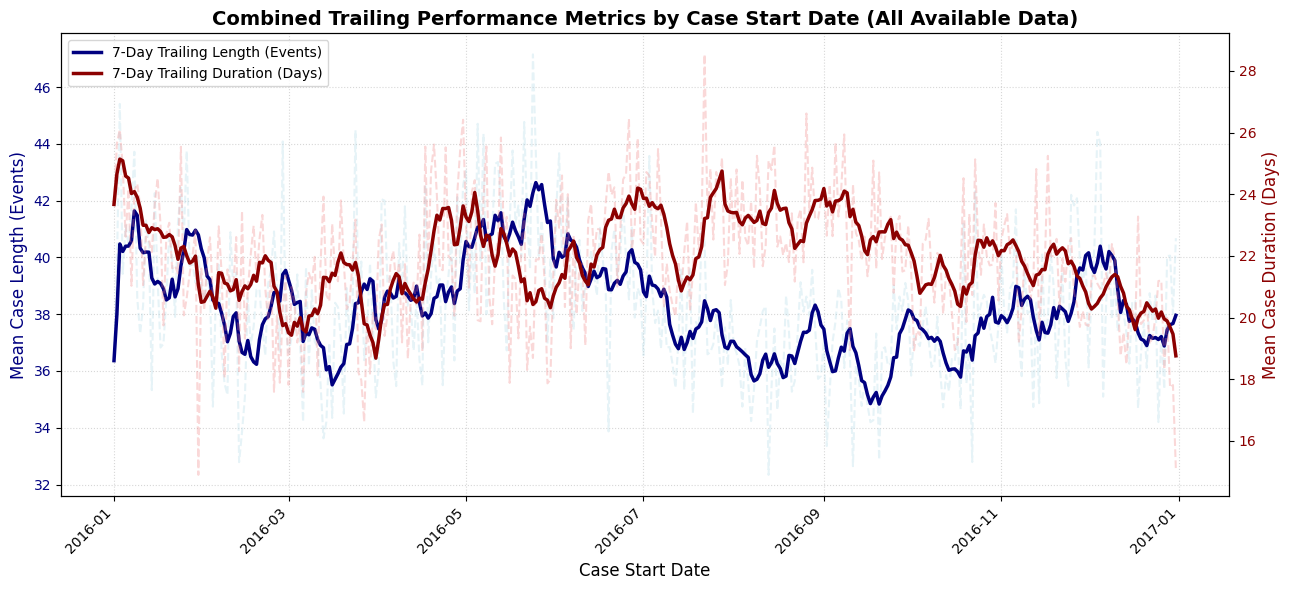

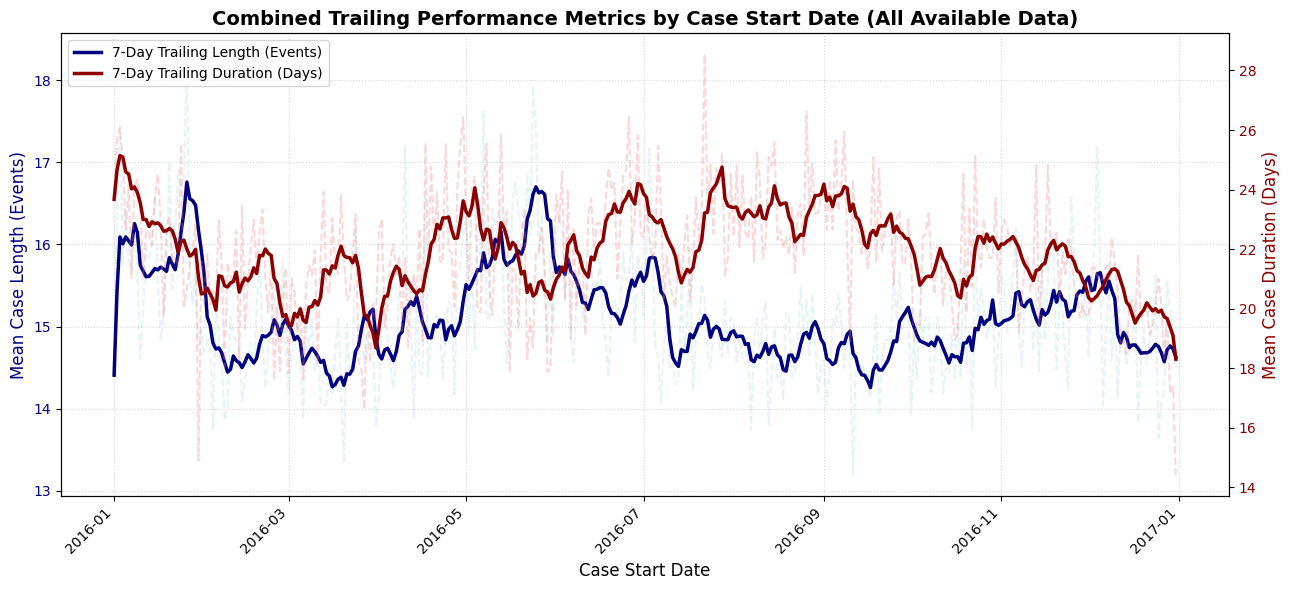

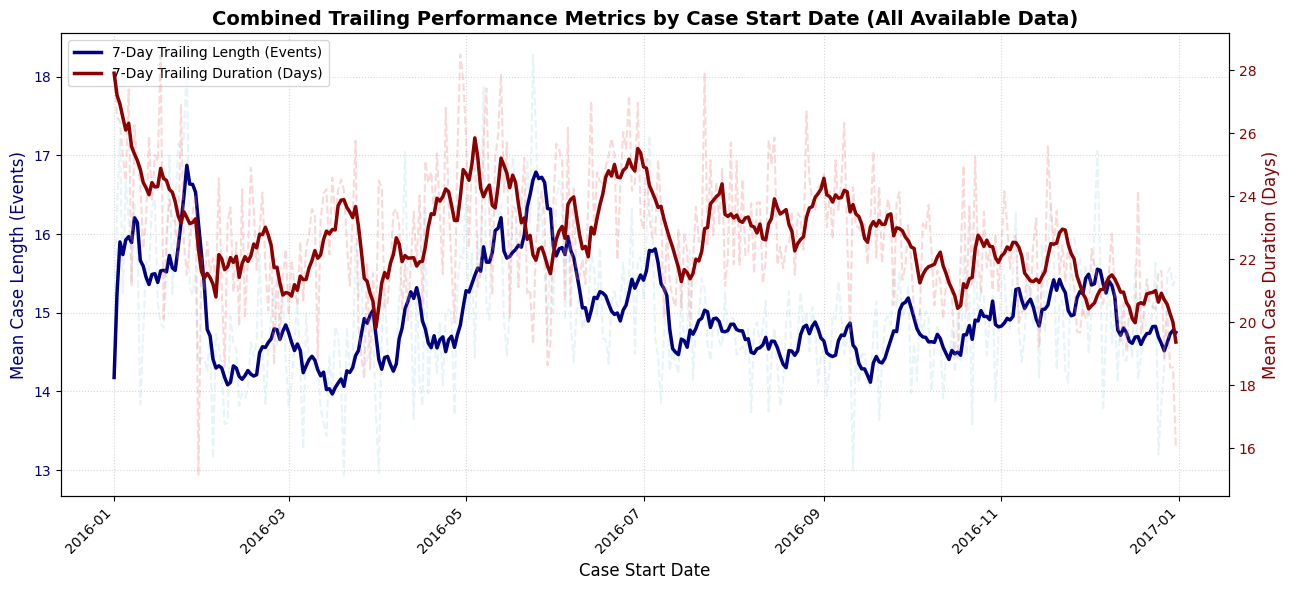

In [53]:
display_combined_trailing_metrics_plot(raw_event_log)
display_combined_trailing_metrics_plot(complete_event_log)
display_combined_trailing_metrics_plot(filtered_event_log)

- explore colleration

In [70]:
def calculate_log_correlation(log_df, log_name):
    # 1. Ensure the timestamp column is explicitly in datetime format
    log_df['time:timestamp'] = pd.to_datetime(log_df['time:timestamp'], utc=True)
    
    # 2. Calculate Case Length (number of events per case)
    case_length = log_df.groupby('case:concept:name').size().rename('case_length')
    
    # 3. Calculate Case Duration in seconds (Max timestamp - Min timestamp per case)
    case_duration = log_df.groupby('case:concept:name')['time:timestamp'].agg(
        lambda x: (x.max() - x.min()).total_seconds()
    ).rename('case_duration')
    
    # 4. Combine into a single DataFrame to guarantee row alignment by case key
    case_stats = pd.concat([case_length, case_duration], axis=1)
    
    # 5. Compute Pearson and Spearman correlation coefficients
    pearson_corr = case_stats['case_length'].corr(case_stats['case_duration'], method='pearson')
    spearman_corr = case_stats['case_length'].corr(case_stats['case_duration'], method='spearman')
    
    return {
        'Log Name': log_name,
        'Pearson (Linear)': round(pearson_corr, 4),
        'Spearman (Rank/Monotonic)': round(spearman_corr, 4)
    }

# Map your dataframes into a dictionary for clean iteration
logs_to_analyze = {
    'Raw Event Log': raw_event_log,
    'Complete Event Log': complete_event_log,
    'Filtered Event Log': filtered_event_log
}

# Run analysis and gather metrics
summary_results = []
for name, df in logs_to_analyze.items():
    metrics = calculate_log_correlation(df, name)
    summary_results.append(metrics)

# Format and display the final comparison table
comparison_df = pd.DataFrame(summary_results).set_index('Log Name')
comparison_df

,Pearson (Linear),Spearman (Rank/Monotonic)
Log Name,,
Raw Event Log,0.1170,-0.0400
Complete Event Log,0.0994,-0.0397
Filtered Event Log,0.0627,-0.0905


- compare process variants and when they cover how many cases in percent

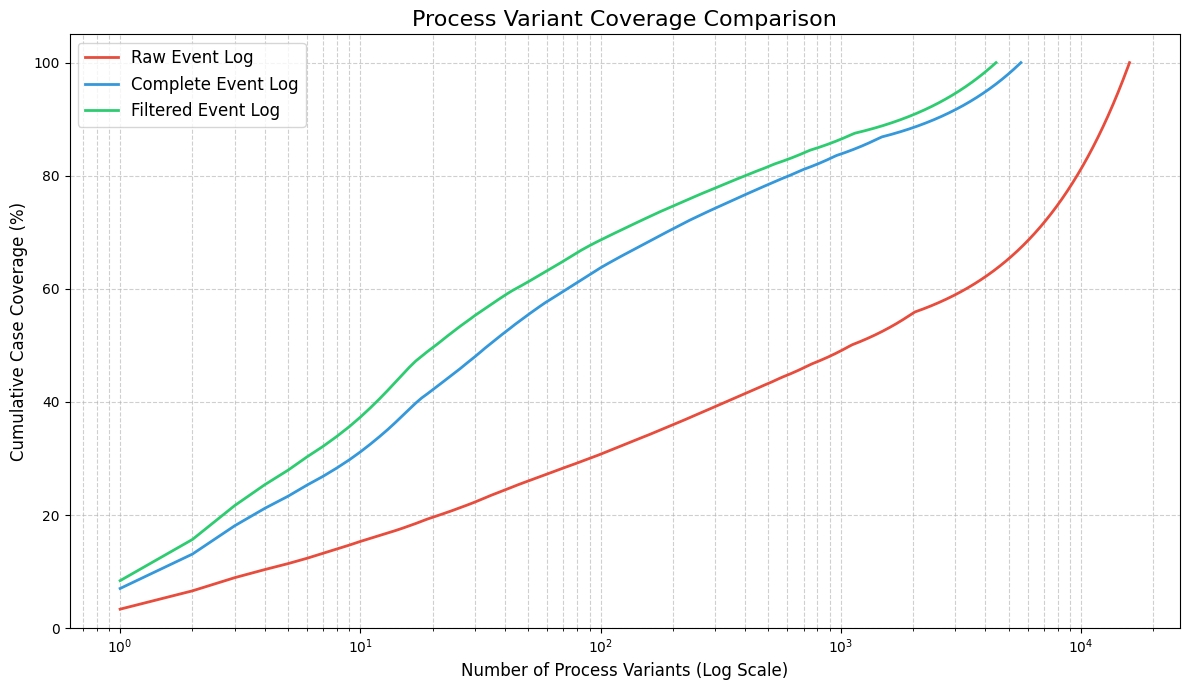

In [68]:

def calculate_cumulative_coverage(log):
    """
    Calculates the cumulative percentage of cases covered by process variants.
    """
    # Extract variants 
    variants = pm4py.get_variants(log)
    
    # Check if there are any variants (edge case handling)
    if not variants:
        return np.array([])

    # Check the type of the values in the dictionary
    first_val = next(iter(variants.values()))
    
    if isinstance(first_val, int):
        # If the values are already integers (counts), just sort them directly
        variant_counts = sorted(variants.values(), reverse=True)
    else:
        # If the values are lists of traces, get their lengths
        variant_counts = sorted([len(traces) for traces in variants.values()], reverse=True)
    
    total_cases = sum(variant_counts)
    cumulative_counts = np.cumsum(variant_counts)
    
    # Convert to cumulative percentages
    cumulative_percentage = (cumulative_counts / total_cases) * 100
    
    return cumulative_percentage


cov_raw = calculate_cumulative_coverage(raw_event_log)
cov_complete = calculate_cumulative_coverage(complete_event_log)
cov_filtered = calculate_cumulative_coverage(filtered_event_log)

# 3. Create the plot
plt.figure(figsize=(12, 7))

# Plot each array. The x-axis is the variant rank (1 to N)
plt.plot(range(1, len(cov_raw) + 1), cov_raw, label='Raw Event Log', linewidth=2, color='#e74c3c')
plt.plot(range(1, len(cov_complete) + 1), cov_complete, label='Complete Event Log', linewidth=2, color='#3498db')
plt.plot(range(1, len(cov_filtered) + 1), cov_filtered, label='Filtered Event Log', linewidth=2, color='#2ecc71')

# Set x-axis to logarithmic scale
plt.xscale('log')

# Formatting the plot
plt.title('Process Variant Coverage Comparison', fontsize=16)
plt.xlabel('Number of Process Variants (Log Scale)', fontsize=12)
plt.ylabel('Cumulative Case Coverage (%)', fontsize=12)
plt.ylim(0, 105)

# Add gridlines that show up nicely on the log scale
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

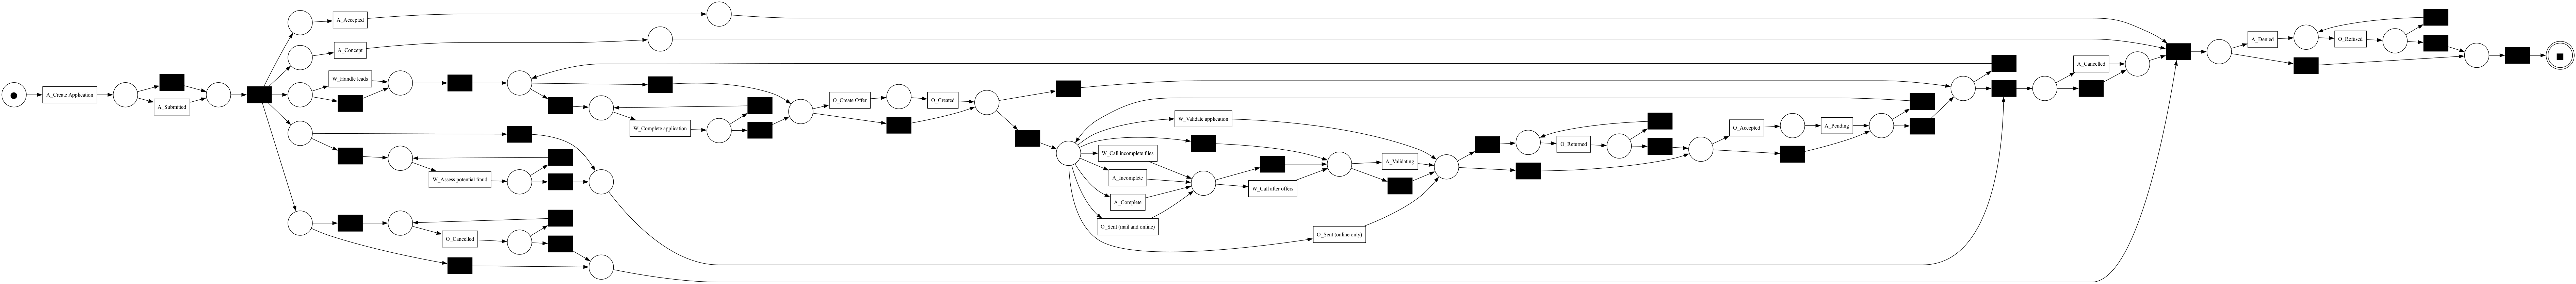

In [55]:
inductive_net, inductive_im, inductive_fm = pm4py.discover_petri_net_inductive(filtered_event_log)
pm4py.view_petri_net(inductive_net, inductive_im, inductive_fm)

In [59]:
# Define the target directory and file name for saving the Petri net visualization
target_dir = "../petrinets/basic_filtered"
file_name = "petri_net_inductive.pdf"
net_name = "inductive_net.pnml"
full_path = os.path.join(target_dir, file_name)
net_path = os.path.join(target_dir, net_name)

# create target directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# Save the Petri net visualization to a file
pm4py.save_vis_petri_net(inductive_net, inductive_im, inductive_fm, full_path)

# Save the Petri net model
pm4py.write_pnml(inductive_net, inductive_im, inductive_fm, net_path)

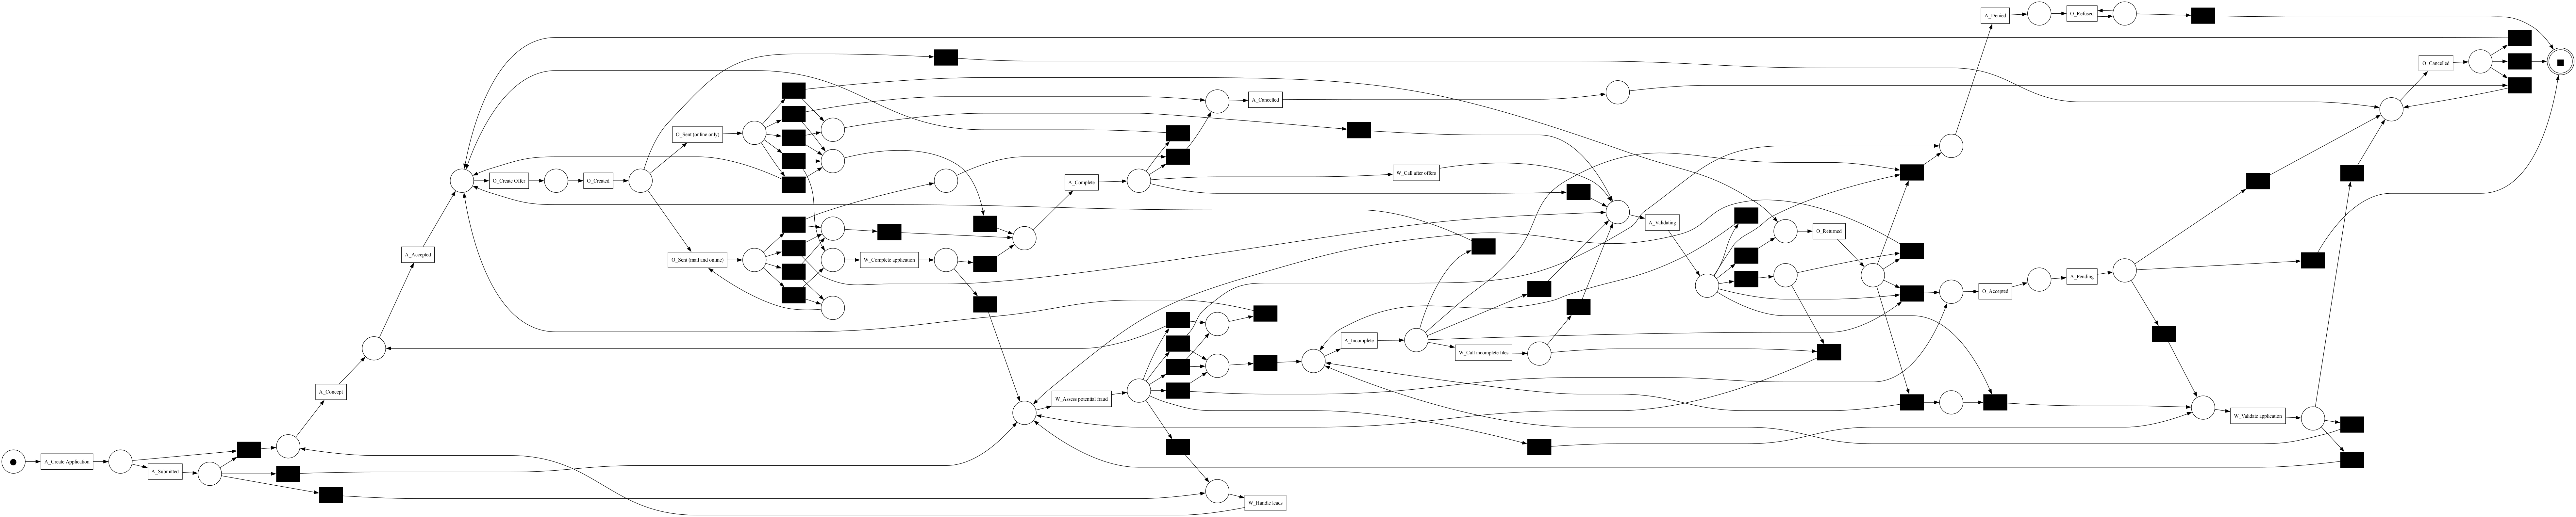

In [56]:
heuristic_net, heuristic_im, heuristic_fm = pm4py.discover_petri_net_heuristics(filtered_event_log)
pm4py.view_petri_net(heuristic_net, heuristic_im, heuristic_fm)

In [60]:
# Define the target directory and file name for saving the Petri net visualization
target_dir = "../petrinets/basic_filtered"
file_name = "petri_net_heuristics.pdf"
net_name = "heuristics_model.pnml"
full_path = os.path.join(target_dir, file_name)
net_path = os.path.join(target_dir, net_name)

# create target directory if it doesn't exist
if not os.path.exists(target_dir):
    os.makedirs(target_dir)

# Save the Petri net visualization to a file
pm4py.save_vis_petri_net(heuristic_net, heuristic_im, heuristic_fm, full_path)

# Save the Petri net model
pm4py.write_pnml(heuristic_net, heuristic_im, heuristic_fm, net_path)

In the book [3], the following metrics are mentioned as candidates for simplicity metrics by analyzing the complexity of the underlying graph:
- Size
- Diameter
- Density
- Connectivity
- Node Degree

Given that the graph functions as a process model, additional domain-specific metrics can be applied:

- Sequentiality: Gateway arcs divided by total arcs.
- Structuredness: Proportion of reducible, well-structured parts in the model.
- Depth: Average or max depth of split/join constructs.
- Gateway Mismatch: Difference between input and output arcs for connected gateways.
- Gateway Heterogeneity: Entropy of gateway types used.
- Control Flow Complexity: Sum of choices based on split types and outgoing arcs.
- Cyclicity: Ratio of nodes in cycles to total nodes.
- Token Splits: Number of concurrent threads from AND/OR-splits.


[3] Josep Carmona, Boudewijn F. van Dongen, Andreas Solti, and Matthias Weidlich. *Conformance Checking - Relating Processes and Models*. Springer, 2018, pp. 223–224.

In [61]:
def calculate_node_size(net):
    """
    Calculates the total number of nodes in a pm4py Petri net.
    Nodes = Places + Transitions
    """
    num_places = len(net.places)
    num_transitions = len(net.transitions)
    
    return num_places + num_transitions

def calculate_arc_size(net):
    """
    Calculates the total number of arcs (edges) in a pm4py Petri net.
    """
    return len(net.arcs)

In [62]:
def calculate_cyclicity(net):
    """
    Calculates the cyclicity of a pm4py Petri net.
    Cyclicity = (number of nodes within cycles) / (total number of nodes)
    
    :param net: pm4py Petri net object
    :return: Float representing the cyclicity metric (between 0.0 and 1.0)
    """
    # 1. Calculate total number of nodes (Places + Transitions)
    total_nodes = len(net.places) + len(net.transitions)
    
    if total_nodes == 0:
        return 0.0
        
    # 2. Build a NetworkX Directed Graph
    G = nx.DiGraph()
    
    # Add all places and transitions as nodes
    for place in net.places:
        G.add_node(place)
    for transition in net.transitions:
        G.add_node(transition)
        
    # Add all arcs as directed edges
    for arc in net.arcs:
        G.add_edge(arc.source, arc.target)
        
    # 3. Identify nodes in cycles
    # A node is in a cycle if it is part of a Strongly Connected Component (SCC)
    # with more than 1 node, or if it is a single node with a self-loop.
    nodes_in_cycles = set()
    
    for scc in nx.strongly_connected_components(G):
        if len(scc) > 1:
            # All nodes in an SCC of size > 1 are part of a cycle
            nodes_in_cycles.update(scc)
        elif len(scc) == 1:
            # Check for self-loops for single-node components
            node = list(scc)[0]
            if G.has_edge(node, node):
                nodes_in_cycles.add(node)
                
    # 4. Calculate the cyclicity ratio
    cyclicity = len(nodes_in_cycles) / total_nodes
    
    return cyclicity

compute all renevant PM4PY quality metrics and the two simplicity metrics

In [65]:
inductive_generalization = pm4py.algo.evaluation.generalization.variants.token_based.apply(filtered_event_log, inductive_net, inductive_im, inductive_fm)
inductive_generalization_all = pm4py.algo.evaluation.generalization.variants.token_based.apply(complete_event_log, inductive_net, inductive_im, inductive_fm)
inductive_precision = pm4py.algo.evaluation.precision.variants.etconformance_token.apply(filtered_event_log, inductive_net, inductive_im, inductive_fm)
inductive_precision_all = pm4py.algo.evaluation.precision.variants.etconformance_token.apply(complete_event_log, inductive_net, inductive_im, inductive_fm)
inductive_fitness = pm4py.algo.evaluation.replay_fitness.variants.token_replay.apply(filtered_event_log, inductive_net, inductive_im, inductive_fm)
inductive_fitness_all = pm4py.algo.evaluation.replay_fitness.variants.token_replay.apply(complete_event_log, inductive_net, inductive_im, inductive_fm)
inductive_node_size = calculate_node_size(inductive_net)
inductive_arc_size = calculate_arc_size(inductive_net)
inductive_cyclicity = calculate_cyclicity(inductive_net)

heuristic_generalization = pm4py.algo.evaluation.generalization.variants.token_based.apply(filtered_event_log, heuristic_net, heuristic_im, heuristic_fm)
heuristic_generalization_all = pm4py.algo.evaluation.generalization.variants.token_based.apply(complete_event_log, heuristic_net, heuristic_im, heuristic_fm)
heuristic_precision = pm4py.algo.evaluation.precision.variants.etconformance_token.apply(filtered_event_log, heuristic_net, heuristic_im, heuristic_fm)
heuristic_precision_all = pm4py.algo.evaluation.precision.variants.etconformance_token.apply(complete_event_log, heuristic_net, heuristic_im, heuristic_fm)
heuristic_fitness = pm4py.algo.evaluation.replay_fitness.variants.token_replay.apply(filtered_event_log, heuristic_net, heuristic_im, heuristic_fm)
heuristic_fitness_all = pm4py.algo.evaluation.replay_fitness.variants.token_replay.apply(complete_event_log, heuristic_net, heuristic_im, heuristic_fm)
heuristic_node_size = calculate_node_size(heuristic_net)
heuristic_arc_size = calculate_arc_size(heuristic_net)
heuristic_cyclicity = calculate_cyclicity(heuristic_net)


replaying log with TBR, completed traces ::   0%|          | 0/4430 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/24378 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27816 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/4430 [00:00<?, ?it/s]

...

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/24378 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27816 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/4430 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

In [66]:

# Initialize the dictionary with lists for both conformance and simplicity metrics
metrics_dict = {
    'Model': [],
    'Fitness (Log)': [],
    'Fitness (Avg Trace)': [],
    'Fitness (% Fit Traces)': [],
    'Precision': [],
    'Generalization': [],
    'Node Size': [],
    'Arc Size': [],
    'Cyclicity': []
}

# Add base models specifying which log was used for evaluation
metrics_dict['Model'].extend([
    'Inductive Miner (Filtered Log)', 
    'Inductive Miner (Complete Log)', 
    'Heuristics Miner (Filtered Log)',
    'Heuristics Miner (Complete Log)'
])

# Add Conformance Metrics 
metrics_dict['Fitness (Log)'].extend([
    inductive_fitness['log_fitness'], 
    inductive_fitness_all['log_fitness'], 
    heuristic_fitness['log_fitness'],
    heuristic_fitness_all['log_fitness']
])

metrics_dict['Fitness (Avg Trace)'].extend([
    inductive_fitness['average_trace_fitness'], 
    inductive_fitness_all['average_trace_fitness'], 
    heuristic_fitness['average_trace_fitness'],
    heuristic_fitness_all['average_trace_fitness']
])

metrics_dict['Fitness (% Fit Traces)'].extend([
    inductive_fitness['perc_fit_traces'], 
    inductive_fitness_all['perc_fit_traces'], 
    heuristic_fitness['perc_fit_traces'],
    heuristic_fitness_all['perc_fit_traces']
])

metrics_dict['Precision'].extend([
    inductive_precision, 
    inductive_precision_all, 
    heuristic_precision,
    heuristic_precision_all
])

metrics_dict['Generalization'].extend([
    inductive_generalization, 
    inductive_generalization_all, 
    heuristic_generalization,
    heuristic_generalization_all
])

# Add Simplicity Metrics
# Note: Since simplicity relates to the model structure, the values 
# remain the same regardless of which event log is evaluated against it.
metrics_dict['Node Size'].extend([
    inductive_node_size, 
    inductive_node_size, 
    heuristic_node_size,
    heuristic_node_size
])

metrics_dict['Arc Size'].extend([
    inductive_arc_size, 
    inductive_arc_size, 
    heuristic_arc_size,
    heuristic_arc_size
])

metrics_dict['Cyclicity'].extend([
    inductive_cyclicity, 
    inductive_cyclicity, 
    heuristic_cyclicity,
    heuristic_cyclicity
])

# Create DataFrame
metrics_df = pd.DataFrame(metrics_dict)

# Print the formatted table
print("=" * 145)
print("CONFORMANCE & SIMPLICITY METRICS - DISCOVERED MODELS (Filtered vs Complete Log)")
print("=" * 145)
print(metrics_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("=" * 145)

CONFORMANCE & SIMPLICITY METRICS - DISCOVERED MODELS (Filtered vs Complete Log)
                          Model  Fitness (Log)  Fitness (Avg Trace)  Fitness (% Fit Traces)  Precision  Generalization  Node Size  Arc Size  Cyclicity
 Inductive Miner (Filtered Log)         1.0000               1.0000                100.0000     0.2197          0.9601        101       130     0.5941
 Inductive Miner (Complete Log)         0.9985               0.9984                 92.1483     0.2305          0.9640        101       130     0.5941
Heuristics Miner (Filtered Log)         0.8435               0.8360                  0.0000     0.9974          0.8255        121       176     0.8678
Heuristics Miner (Complete Log)         0.8389               0.8321                  0.0000     0.9971          0.8324        121       176     0.8678


- as the top 401 variants cover 80% of the cases on the filtered event log, we can try to run our discover algorithms again on only the top variants to maybe achieve simpler petri nets, while still having high conformance metrics

In [71]:
output_dir = "../petrinets/top_401"
os.makedirs(output_dir, exist_ok=True) # Cleaner directory creation
# filter log on the top 401 variants
log_401 = pm4py.filter_variants_top_k(filtered_event_log, 401)


# Discover Petri net using Inductive Miner on the top 401 variants log
ind_401_net, ind_401_im, ind_401_fm = pm4py.discover_petri_net_inductive(log_401)
ind_401_path = os.path.join(output_dir, "inductive_miner_top_401.pdf")
pm4py.save_vis_petri_net(ind_401_net, ind_401_im, ind_401_fm, ind_401_path)
pm4py.write_pnml(ind_401_net, ind_401_im, ind_401_fm, os.path.join(output_dir, "inductive_miner_top_401.pnml"))

# Discover Petri net using Heuristics Miner on the top 401 variants log
heu_401_net, heu_401_im, heu_401_fm = pm4py.discover_petri_net_heuristics(log_401)
heu_401_path = os.path.join(output_dir, "heuristics_miner_top_401.pdf")
pm4py.save_vis_petri_net(heu_401_net, heu_401_im, heu_401_fm, heu_401_path)
pm4py.write_pnml(heu_401_net, heu_401_im, heu_401_fm, os.path.join(output_dir, "heuristics_miner_top_401.pnml"))

# Run conformance and simplicity evaluations for the top 401 variants models
ind_401_generalization = pm4py.algo.evaluation.generalization.variants.token_based.apply(filtered_event_log, ind_401_net, ind_401_im, ind_401_fm)
ind_401_generalization_all = pm4py.algo.evaluation.generalization.variants.token_based.apply(complete_event_log, ind_401_net, ind_401_im, ind_401_fm)

ind_401_precision = pm4py.algo.evaluation.precision.variants.etconformance_token.apply(filtered_event_log, ind_401_net, ind_401_im, ind_401_fm)
ind_401_precision_all = pm4py.algo.evaluation.precision.variants.etconformance_token.apply(complete_event_log, ind_401_net, ind_401_im, ind_401_fm)

ind_401_fitness = pm4py.algo.evaluation.replay_fitness.variants.token_replay.apply(filtered_event_log, ind_401_net, ind_401_im, ind_401_fm)
ind_401_fitness_all = pm4py.algo.evaluation.replay_fitness.variants.token_replay.apply(complete_event_log, ind_401_net, ind_401_im, ind_401_fm)

ind_401_node_size = calculate_node_size(ind_401_net)
ind_401_arc_size = calculate_arc_size(ind_401_net)
ind_401_cyclicity = calculate_cyclicity(ind_401_net)

heu_401_generalization = pm4py.algo.evaluation.generalization.variants.token_based.apply(filtered_event_log, heu_401_net, heu_401_im, heu_401_fm)
heu_401_generalization_all = pm4py.algo.evaluation.generalization.variants.token_based.apply(complete_event_log, heu_401_net, heu_401_im, heu_401_fm)

heu_401_precision = pm4py.algo.evaluation.precision.variants.etconformance_token.apply(filtered_event_log, heu_401_net, heu_401_im, heu_401_fm)
heu_401_precision_all = pm4py.algo.evaluation.precision.variants.etconformance_token.apply(complete_event_log, heu_401_net, heu_401_im, heu_401_fm)

heu_401_fitness = pm4py.algo.evaluation.replay_fitness.variants.token_replay.apply(filtered_event_log, heu_401_net, heu_401_im, heu_401_fm)
heu_401_fitness_all = pm4py.algo.evaluation.replay_fitness.variants.token_replay.apply(complete_event_log, heu_401_net, heu_401_im, heu_401_fm)

heu_401_node_size = calculate_node_size(heu_401_net)
heu_401_arc_size = calculate_arc_size(heu_401_net)
heu_401_cyclicity = calculate_cyclicity(heu_401_net)    

replaying log with TBR, completed traces ::   0%|          | 0/4430 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/24378 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27816 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/4430 [00:00<?, ?it/s]

...

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/24378 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27816 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/4430 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

In [72]:
# Initialize the dictionary with lists for both conformance and simplicity metrics
metrics_401_dict = {
    'Model': [],
    'Fitness (Log)': [],
    'Fitness (Avg Trace)': [],
    'Fitness (% Fit Traces)': [],
    'Precision': [],
    'Generalization': [],
    'Node Size': [],
    'Arc Size': [],
    'Cyclicity': []
}

# Add top 401 models specifying which log was used for evaluation
metrics_401_dict['Model'].extend([
    'Inductive Miner Top 401 (Filtered Log)',
    'Inductive Miner Top 401 (Complete Log)',
    'Heuristics Miner Top 401 (Filtered Log)',
    'Heuristics Miner Top 401 (Complete Log)'
])

# Add Conformance Metrics
metrics_401_dict['Fitness (Log)'].extend([
    ind_401_fitness['log_fitness'],
    ind_401_fitness_all['log_fitness'],
    heu_401_fitness['log_fitness'],
    heu_401_fitness_all['log_fitness']
])

metrics_401_dict['Fitness (Avg Trace)'].extend([
    ind_401_fitness['average_trace_fitness'],
    ind_401_fitness_all['average_trace_fitness'],
    heu_401_fitness['average_trace_fitness'],
    heu_401_fitness_all['average_trace_fitness']
])

metrics_401_dict['Fitness (% Fit Traces)'].extend([
    ind_401_fitness['perc_fit_traces'],
    ind_401_fitness_all['perc_fit_traces'],
    heu_401_fitness['perc_fit_traces'],
    heu_401_fitness_all['perc_fit_traces']
])

metrics_401_dict['Precision'].extend([
    ind_401_precision,
    ind_401_precision_all,
    heu_401_precision,
    heu_401_precision_all
])

metrics_401_dict['Generalization'].extend([
    ind_401_generalization,
    ind_401_generalization_all,
    heu_401_generalization,
    heu_401_generalization_all
])

# Add Simplicity Metrics
# Note: Since simplicity relates to the model structure, the values
# remain the same regardless of which event log is evaluated against it.
metrics_401_dict['Node Size'].extend([
    ind_401_node_size,
    ind_401_node_size,
    heu_401_node_size,
    heu_401_node_size
])

metrics_401_dict['Arc Size'].extend([
    ind_401_arc_size,
    ind_401_arc_size,
    heu_401_arc_size,
    heu_401_arc_size
])

metrics_401_dict['Cyclicity'].extend([
    ind_401_cyclicity,
    ind_401_cyclicity,
    heu_401_cyclicity,
    heu_401_cyclicity
])

# Create DataFrame
metrics_401_df = pd.DataFrame(metrics_401_dict)

# Print the formatted table
print("=" * 145)
print("CONFORMANCE & SIMPLICITY METRICS - TOP 401 VARIANTS MODELS (Filtered vs Complete Log)")
print("=" * 145)
print(metrics_401_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("=" * 145)

CONFORMANCE & SIMPLICITY METRICS - TOP 401 VARIANTS MODELS (Filtered vs Complete Log)
                                  Model  Fitness (Log)  Fitness (Avg Trace)  Fitness (% Fit Traces)  Precision  Generalization  Node Size  Arc Size  Cyclicity
 Inductive Miner Top 401 (Filtered Log)         0.9991               0.9994                 97.4654     0.4663          0.9861        105       132     0.5714
 Inductive Miner Top 401 (Complete Log)         0.9971               0.9973                 89.7902     0.4754          0.9884        105       132     0.5714
Heuristics Miner Top 401 (Filtered Log)         0.8193               0.8119                  0.0000     0.9992          0.9211         89       122     0.6292
Heuristics Miner Top 401 (Complete Log)         0.8124               0.8056                  0.0000     0.9990          0.9243         89       122     0.6292


- as the Conformance metrics are still good, but the simplicity is still low, we want to consider training on an even less variants. 100 variants cover 68.63 percent lets try another iteration:

In [76]:
# 1. Extract variants from your event log
variants_dict = pm4py.get_variants(filtered_event_log)

# 2. Extract the counts for each variant
first_val = next(iter(variants_dict.values()))
if isinstance(first_val, int):
    # If the dictionary values are already counts
    variant_counts = pd.Series(variants_dict)
else:
    # If the dictionary values are lists of traces
    variant_counts = pd.Series({k: len(v) for k, v in variants_dict.items()})

# 3. Sort the counts in descending order
variant_counts = variant_counts.sort_values(ascending=False)

# 4. Calculate the cumulative percentage of cases covered
variant_coverage_series = (variant_counts.cumsum() / variant_counts.sum()) * 100

# 5. Get the coverage for the top 100 variants (index 99)
top_100_coverage = variant_coverage_series.iloc[99]

print(f"The top 100 process variants cover {top_100_coverage:.2f}% of cases.")

The top 100 process variants cover 68.63% of cases.


In [73]:
output_dir = "../petrinets/top_100"
os.makedirs(output_dir, exist_ok=True) # Cleaner directory creation
# filter log on the top 100 variants
log_100 = pm4py.filter_variants_top_k(filtered_event_log, 100)


# Discover Petri net using Inductive Miner on the top 100 variants log
ind_100_net, ind_100_im, ind_100_fm = pm4py.discover_petri_net_inductive(log_100)
ind_100_path = os.path.join(output_dir, "inductive_miner_top_100.pdf")
pm4py.save_vis_petri_net(ind_100_net, ind_100_im, ind_100_fm, ind_100_path)
pm4py.write_pnml(ind_100_net, ind_100_im, ind_100_fm, os.path.join(output_dir, "inductive_miner_top_100.pnml"))

# Discover Petri net using Heuristics Miner on the top 100 variants log
heu_100_net, heu_100_im, heu_100_fm = pm4py.discover_petri_net_heuristics(log_100)
heu_100_path = os.path.join(output_dir, "heuristics_miner_top_100.pdf")
pm4py.save_vis_petri_net(heu_100_net, heu_100_im, heu_100_fm, heu_100_path)
pm4py.write_pnml(heu_100_net, heu_100_im, heu_100_fm, os.path.join(output_dir, "heuristics_miner_top_100.pnml"))

# Run conformance and simplicity evaluations for the top 100 variants models
ind_100_generalization = pm4py.algo.evaluation.generalization.variants.token_based.apply(filtered_event_log, ind_100_net, ind_100_im, ind_100_fm)
ind_100_generalization_all = pm4py.algo.evaluation.generalization.variants.token_based.apply(complete_event_log, ind_100_net, ind_100_im, ind_100_fm)

ind_100_precision = pm4py.algo.evaluation.precision.variants.etconformance_token.apply(filtered_event_log, ind_100_net, ind_100_im, ind_100_fm)
ind_100_precision_all = pm4py.algo.evaluation.precision.variants.etconformance_token.apply(complete_event_log, ind_100_net, ind_100_im, ind_100_fm)

ind_100_fitness = pm4py.algo.evaluation.replay_fitness.variants.token_replay.apply(filtered_event_log, ind_100_net, ind_100_im, ind_100_fm)
ind_100_fitness_all = pm4py.algo.evaluation.replay_fitness.variants.token_replay.apply(complete_event_log, ind_100_net, ind_100_im, ind_100_fm)

ind_100_node_size = calculate_node_size(ind_100_net)
ind_100_arc_size = calculate_arc_size(ind_100_net)
ind_100_cyclicity = calculate_cyclicity(ind_100_net)

heu_100_generalization = pm4py.algo.evaluation.generalization.variants.token_based.apply(filtered_event_log, heu_100_net, heu_100_im, heu_100_fm)
heu_100_generalization_all = pm4py.algo.evaluation.generalization.variants.token_based.apply(complete_event_log, heu_100_net, heu_100_im, heu_100_fm)

heu_100_precision = pm4py.algo.evaluation.precision.variants.etconformance_token.apply(filtered_event_log, heu_100_net, heu_100_im, heu_100_fm)
heu_100_precision_all = pm4py.algo.evaluation.precision.variants.etconformance_token.apply(complete_event_log, heu_100_net, heu_100_im, heu_100_fm)

heu_100_fitness = pm4py.algo.evaluation.replay_fitness.variants.token_replay.apply(filtered_event_log, heu_100_net, heu_100_im, heu_100_fm)
heu_100_fitness_all = pm4py.algo.evaluation.replay_fitness.variants.token_replay.apply(complete_event_log, heu_100_net, heu_100_im, heu_100_fm)

heu_100_node_size = calculate_node_size(heu_100_net)
heu_100_arc_size = calculate_arc_size(heu_100_net)
heu_100_cyclicity = calculate_cyclicity(heu_100_net)    

replaying log with TBR, completed traces ::   0%|          | 0/4430 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/24378 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27816 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/4430 [00:00<?, ?it/s]

...

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/24378 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27816 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/4430 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

In [74]:
# Initialize the dictionary with lists for both conformance and simplicity metrics
metrics_100_dict = {
    'Model': [],
    'Fitness (Log)': [],
    'Fitness (Avg Trace)': [],
    'Fitness (% Fit Traces)': [],
    'Precision': [],
    'Generalization': [],
    'Node Size': [],
    'Arc Size': [],
    'Cyclicity': []
}

# Add top 100 models specifying which log was used for evaluation
metrics_100_dict['Model'].extend([
    'Inductive Miner Top 100 (Filtered Log)',
    'Inductive Miner Top 100 (Complete Log)',
    'Heuristics Miner Top 100 (Filtered Log)',
    'Heuristics Miner Top 100 (Complete Log)'
])

# Add Conformance Metrics
metrics_100_dict['Fitness (Log)'].extend([
    ind_100_fitness['log_fitness'],
    ind_100_fitness_all['log_fitness'],
    heu_100_fitness['log_fitness'],
    heu_100_fitness_all['log_fitness']
])

metrics_100_dict['Fitness (Avg Trace)'].extend([
    ind_100_fitness['average_trace_fitness'],
    ind_100_fitness_all['average_trace_fitness'],
    heu_100_fitness['average_trace_fitness'],
    heu_100_fitness_all['average_trace_fitness']
])

metrics_100_dict['Fitness (% Fit Traces)'].extend([
    ind_100_fitness['perc_fit_traces'],
    ind_100_fitness_all['perc_fit_traces'],
    heu_100_fitness['perc_fit_traces'],
    heu_100_fitness_all['perc_fit_traces']
])

metrics_100_dict['Precision'].extend([
    ind_100_precision,
    ind_100_precision_all,
    heu_100_precision,
    heu_100_precision_all
])

metrics_100_dict['Generalization'].extend([
    ind_100_generalization,
    ind_100_generalization_all,
    heu_100_generalization,
    heu_100_generalization_all
])

# Add Simplicity Metrics
# Note: Since simplicity relates to the model structure, the values
# remain the same regardless of which event log is evaluated against it.
metrics_100_dict['Node Size'].extend([
    ind_100_node_size,
    ind_100_node_size,
    heu_100_node_size,
    heu_100_node_size
])

metrics_100_dict['Arc Size'].extend([
    ind_100_arc_size,
    ind_100_arc_size,
    heu_100_arc_size,
    heu_100_arc_size
])

metrics_100_dict['Cyclicity'].extend([
    ind_100_cyclicity,
    ind_100_cyclicity,
    heu_100_cyclicity,
    heu_100_cyclicity
])

# Create DataFrame
metrics_100_df = pd.DataFrame(metrics_100_dict)

# Print the formatted table
print("=" * 145)
print("CONFORMANCE & SIMPLICITY METRICS - TOP 100 VARIANTS MODELS (Filtered vs Complete Log)")
print("=" * 145)
print(metrics_100_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("=" * 145)

CONFORMANCE & SIMPLICITY METRICS - TOP 100 VARIANTS MODELS (Filtered vs Complete Log)
                                  Model  Fitness (Log)  Fitness (Avg Trace)  Fitness (% Fit Traces)  Precision  Generalization  Node Size  Arc Size  Cyclicity
 Inductive Miner Top 100 (Filtered Log)         0.9916               0.9944                 87.7831     0.5225          0.9896         93       116     0.4516
 Inductive Miner Top 100 (Complete Log)         0.9897               0.9923                 81.9861     0.5313          0.9908         93       116     0.4516
Heuristics Miner Top 100 (Filtered Log)         0.8390               0.8368                  0.0000     0.9997          0.9327         62        81     0.5806
Heuristics Miner Top 100 (Complete Log)         0.8325               0.8304                  0.0000     0.9997          0.9338         62        81     0.5806
